# 과제 - PyTorch로 mini GPT 구현

이 노트북은 과제 안내서의 구현 순서를 그대로 따릅니다.

1. 환경설정
2. NSMC 데이터 준비
3. BPE 토크나이저
4. GPTDataset / InputEmbedding
5. MultiHeadAttention
6. GPTModel
7. 사전 학습 유틸리티
8. 감성 분류 미세 조정

각 단계의 `src/` TODO를 구현한 뒤, 바로 아래 pytest 셀로 해당 단계만 확인하세요.

## 1. 환경설정

Colab에서는 GitHub 저장소 URL과 GitHub Personal Access Token을 입력해 저장소를 clone하고 `src/`를 import 경로에 추가합니다.
로컬 VS Code에서는 현재 폴더를 프로젝트 루트로 보고 실행합니다.

In [1]:
# Colab: 이 셀을 가장 먼저 실행하세요.
import os
import subprocess
import sys
from pathlib import Path


def normalize_github_url(url: str) -> str:
    """Colab 입력값을 git clone에 사용할 수 있는 https URL로 정리합니다."""
    url = url.strip()
    if not url:
        raise ValueError("GitHub 저장소 URL을 입력해야 합니다.")
    if url.startswith("github.com/"):
        url = "https://" + url
    if not url.startswith("https://"):
        raise ValueError("저장소 URL은 https://github.com/... 또는 github.com/... 형식이어야 합니다.")
    url = url.rstrip("/")
    if not url.endswith(".git"):
        url += ".git"
    return url


if "google.colab" in sys.modules:
    from getpass import getpass

    repo_url = normalize_github_url(input("GitHub 저장소 URL (예: github.com/Jungle-12-303/week13-14_team1_llm.git): "))
    token = getpass("GitHub Personal Access Token (Private 저장소인 경우 입력, 공개 저장소면 Enter): ").strip()
    clone_url = repo_url.replace("https://", f"https://{token}@") if token else repo_url
    repo_name = Path(repo_url[:-4]).name if repo_url.endswith(".git") else Path(repo_url).name
    repo_dir = Path("/content") / repo_name

    if not repo_dir.exists():
        subprocess.run(["git", "clone", clone_url, str(repo_dir)], check=True)
        subprocess.run(["git", "remote", "set-url", "origin", repo_url], cwd=repo_dir, check=True)
    else:
        print(f"이미 clone된 저장소를 사용합니다: {repo_dir}")

    os.chdir(repo_dir)
else:
    repo_dir = Path(".").resolve()

sys.path.insert(0, str(repo_dir / "src"))
print(f"Repo: {repo_dir}")

Repo: E:\jungle\week13-14_team1_llm


In [2]:
# 단계별 테스트 실행 helper
import subprocess
import sys


def run_pytest(target: str):
    cmd = [sys.executable, "-m", "pytest", target, "-v"]
    print("실행 명령:", " ".join(cmd))
    result = subprocess.run(cmd, cwd=str(repo_dir), text=True, capture_output=True)
    print(result.stdout)
    if result.stderr:
        print(result.stderr)
    if result.returncode != 0:
        print("\n아직 통과하지 못한 테스트가 있습니다. 해당 단계의 TODO를 먼저 구현하세요.")
    else:
        print("\n선택한 테스트를 통과했습니다.")
    return result.returncode

## 2. NSMC 데이터 준비

기본 데이터는 NAVER Sentiment Movie Corpus(NSMC)입니다.
`download_data.py`는 원본 TSV를 내려받고, 사전 학습용 텍스트와 감성 분류용 JSONL을 만듭니다.

In [3]:
from pathlib import Path

try:
    import download_data

    paths = download_data.main()
except Exception as e:
    print("데이터 준비 중 문제가 생겼습니다:", e)
    print("이미 data/ 파일이 있다면 다음 셀부터 계속 진행할 수 있습니다.")

LM_TRAIN_PATH = repo_dir / "data" / "nsmc_lm_train.txt"
LM_VAL_PATH = repo_dir / "data" / "nsmc_lm_val.txt"
print("LM train exists:", LM_TRAIN_PATH.exists(), LM_TRAIN_PATH)
print("LM val exists:", LM_VAL_PATH.exists(), LM_VAL_PATH)

이미 존재합니다: e:\jungle\week13-14_team1_llm\data\ratings_train.txt
이미 존재합니다: e:\jungle\week13-14_team1_llm\data\ratings_test.txt
사전 학습 train 텍스트: e:\jungle\week13-14_team1_llm\data\nsmc_lm_train.txt (1,379,486자)
사전 학습 val 텍스트: e:\jungle\week13-14_team1_llm\data\nsmc_lm_val.txt (120,560자)
감성 분류 train: e:\jungle\week13-14_team1_llm\data\nsmc_sentiment_train.jsonl (137,996개)
감성 분류 val: e:\jungle\week13-14_team1_llm\data\nsmc_sentiment_val.jsonl (11,999개)
감성 분류 test: e:\jungle\week13-14_team1_llm\data\nsmc_sentiment_test.jsonl (49,997개)
LM train exists: True E:\jungle\week13-14_team1_llm\data\nsmc_lm_train.txt
LM val exists: True E:\jungle\week13-14_team1_llm\data\nsmc_lm_val.txt


In [4]:
corpus = LM_TRAIN_PATH.read_text(encoding="utf-8") if LM_TRAIN_PATH.exists() else ""
val_corpus = LM_VAL_PATH.read_text(encoding="utf-8") if LM_VAL_PATH.exists() else ""
print("train chars:", len(corpus))
print("val chars:", len(val_corpus))
print(corpus[:200])

train chars: 1379486
val chars: 120560
개재미없다. 감독의 연출력의 한계
이제서야 보게된 대 명작 연출미가 정말 훌륭하다!!!!!!!!
소주미라클을 만들어라
귀여운 캐릭터들도 많이 나와서 보러 가야 겠어요..
블랙 코미디가 싫어요.
평점깎고싶다10글자
TV시리즈가 너무재밌어서 영화는 기대안하고 봤는데 역시....최고네요
개인적 공감이 글쎄?
시작은 니시지마 때문에 봤는데 나름 괜찮은 영화 봤다고


## 3. Step 1 - BPE 토크나이저

구현 파일: `src/bpe.py`

먼저 `pytest tests/test_bpe.py -v`를 통과시키세요. 한국어를 안전하게 다루기 위해 UTF-8 byte-level BPE로 구현해야 합니다.

In [5]:
run_pytest("tests/test_bpe.py")

실행 명령: c:\Users\kukur\anaconda3\envs\llm-scratch\python.exe -m pytest tests/test_bpe.py -v
============================= test session starts =============================
platform win32 -- Python 3.10.20, pytest-9.0.3, pluggy-1.6.0 -- c:\Users\kukur\anaconda3\envs\llm-scratch\python.exe
cachedir: .pytest_cache
rootdir: E:\jungle\week13-14_team1_llm
collecting ... collected 6 items

tests/test_bpe.py::TestSpecialTokens::test_special_ids_fixed PASSED      [ 16%]
tests/test_bpe.py::TestBPETokenizer::test_init_special_tokens PASSED     [ 33%]
tests/test_bpe.py::TestBPETokenizer::test_save_load_restores_vocab PASSED [ 50%]
tests/test_bpe.py::TestBPETokenizer::test_encode_decode_restores_original_text PASSED [ 66%]
tests/test_bpe.py::TestBPETokenizer::test_get_special_ids PASSED         [ 83%]
tests/test_bpe.py::TestBPETrain::test_train_increases_vocab PASSED       [100%]

============================== 6 passed in 0.04s ==============================


선택한 테스트를 통과했습니다.


0

In [6]:
# BPE 구현 후 작은 말뭉치로 인코딩/디코딩 복원을 확인합니다.
try:
    from bpe import BPETokenizer

    tokenizer = BPETokenizer(vocab_size=300)
    tokenizer.train(corpus[:5000])
    sample = "이 영화는 정말 좋았다! English 123"
    ids = tokenizer.encode(sample, add_bos_eos=True)
    print(ids[:20])
    print(tokenizer.decode(ids))
except NotImplementedError as e:
    print("BPE TODO 미구현:", e)

[2, 265, 260, 290, 268, 260, 164, 153, 274, 148, 260, 166, 143, 281, 156, 270, 37, 36, 73, 114]
이 영화는 정말 좋았다! English 123


## 4. Step 2 - GPTDataset / InputEmbedding

구현 파일: `src/dataset.py`, `src/embeddings.py`

BPE가 통과한 뒤 데이터셋과 입력 임베딩을 구현합니다.

In [7]:
run_pytest("tests/test_dataset.py")

실행 명령: c:\Users\kukur\anaconda3\envs\llm-scratch\python.exe -m pytest tests/test_dataset.py -v
============================= test session starts =============================
platform win32 -- Python 3.10.20, pytest-9.0.3, pluggy-1.6.0 -- c:\Users\kukur\anaconda3\envs\llm-scratch\python.exe
cachedir: .pytest_cache
rootdir: E:\jungle\week13-14_team1_llm
collecting ... collected 4 items

tests/test_dataset.py::TestGPTDataset::test_dataset_length PASSED        [ 25%]
tests/test_dataset.py::TestGPTDataset::test_dataset_getitem_shape PASSED [ 50%]
tests/test_dataset.py::TestCreateDataloader::test_dataloader_batch_shape PASSED [ 75%]
tests/test_dataset.py::TestInputEmbedding::test_input_embedding_shape PASSED [100%]

============================== 4 passed in 4.89s ==============================


선택한 테스트를 통과했습니다.


0

In [8]:
try:
    from bpe import BPETokenizer
    from dataset import create_dataloader
    from embeddings import InputEmbedding

    tokenizer = BPETokenizer(vocab_size=300)
    tokenizer.train(corpus[:5000])
    token_ids = tokenizer.encode(corpus[:5000])
    loader = create_dataloader(token_ids, context_length=32, batch_size=2, shuffle=False)
    inp, tgt = next(iter(loader))
    emb = InputEmbedding(vocab_size=300, emb_dim=32, context_length=32, drop_rate=0.0)
    out = emb(inp)
    print(inp.shape, tgt.shape, out.shape)
except NotImplementedError as e:
    print("Dataset/Embedding TODO 미구현:", e)

torch.Size([2, 32]) torch.Size([2, 32]) torch.Size([2, 32, 32])


## 5. Step 3 - MultiHeadAttention

구현 파일: `src/attention.py`

Q/K/V shape, head 분리, causal mask를 차례로 확인하세요.

In [9]:
run_pytest("tests/test_attention.py")

실행 명령: c:\Users\kukur\anaconda3\envs\llm-scratch\python.exe -m pytest tests/test_attention.py -v
============================= test session starts =============================
platform win32 -- Python 3.10.20, pytest-9.0.3, pluggy-1.6.0 -- c:\Users\kukur\anaconda3\envs\llm-scratch\python.exe
cachedir: .pytest_cache
rootdir: E:\jungle\week13-14_team1_llm
collecting ... collected 2 items

tests/test_attention.py::TestMultiHeadAttention::test_mha_output_shape PASSED [ 50%]
tests/test_attention.py::TestMultiHeadAttention::test_mha_causal_mask_future_zero PASSED [100%]

============================== 2 passed in 2.52s ==============================


선택한 테스트를 통과했습니다.


0

## 6. Step 4 - GPTModel

구현 파일: `src/model.py`

LayerNorm, GELU, FeedForward, TransformerBlock, GPTModel, `generate_text_simple` 순서로 구현합니다.

In [10]:
run_pytest("tests/test_model.py")

실행 명령: c:\Users\kukur\anaconda3\envs\llm-scratch\python.exe -m pytest tests/test_model.py -v
============================= test session starts =============================
platform win32 -- Python 3.10.20, pytest-9.0.3, pluggy-1.6.0 -- c:\Users\kukur\anaconda3\envs\llm-scratch\python.exe
cachedir: .pytest_cache
rootdir: E:\jungle\week13-14_team1_llm
collecting ... collected 7 items

tests/test_model.py::TestLayerNorm::test_layernorm_shape PASSED          [ 14%]
tests/test_model.py::TestGELU::test_gelu_shape PASSED                    [ 28%]
tests/test_model.py::TestFeedForward::test_feedforward_shape PASSED      [ 42%]
tests/test_model.py::TestTransformerBlock::test_transformer_block_shape PASSED [ 57%]
tests/test_model.py::TestGPTModel::test_gpt_forward_shape PASSED         [ 71%]
tests/test_model.py::TestGPTModel::test_gpt_forward_with_targets_returns_loss PASSED [ 85%]
tests/test_model.py::TestGenerateTextSimple::test_generate_text_simple_shape PASSED [100%]

=======================

0

In [11]:
try:
    import torch
    from model import GPTModel

    config = {
        "vocab_size": 300,
        "context_length": 32,
        "emb_dim": 32,
        "n_heads": 4,
        "n_layers": 1,
        "drop_rate": 0.0,
        "qkv_bias": False,
    }
    model = GPTModel(config)
    x = torch.randint(0, config["vocab_size"], (2, 16))
    logits = model(x)
    print(logits.shape)
except NotImplementedError as e:
    print("Model TODO 미구현:", e)

torch.Size([2, 16, 300])


## 7. Step 5 - 사전 학습 유틸리티

구현 파일: `src/train.py`

loss 계산, checkpoint 저장/로드, temperature/top-k 생성, `train_model`을 구현합니다.

In [12]:
run_pytest("tests/test_train.py")

실행 명령: c:\Users\kukur\anaconda3\envs\llm-scratch\python.exe -m pytest tests/test_train.py -v
============================= test session starts =============================
platform win32 -- Python 3.10.20, pytest-9.0.3, pluggy-1.6.0 -- c:\Users\kukur\anaconda3\envs\llm-scratch\python.exe
cachedir: .pytest_cache
rootdir: E:\jungle\week13-14_team1_llm
collecting ... collected 5 items

tests/test_train.py::TestCalcLossBatch::test_calc_loss_batch_returns_scalar PASSED [ 20%]
tests/test_train.py::TestCalcLossLoader::test_calc_loss_loader_returns_float PASSED [ 40%]
tests/test_train.py::TestCheckpoint::test_save_load_checkpoint_restores_epoch_and_step PASSED [ 60%]
tests/test_train.py::TestGenerate::test_generate_shape PASSED            [ 80%]
tests/test_train.py::TestPlotLosses::test_plot_losses_callable PASSED    [100%]

============================== warnings summary ===============================
tests/test_train.py::TestPlotLosses::test_plot_losses_callable
  E:\jungle\week13-14_team1

0

In [13]:
# 모든 앞 단계가 구현된 뒤 한 배치 smoke test를 실행합니다.
try:
    import torch
    from bpe import BPETokenizer
    from dataset import create_dataloader
    from model import GPTModel
    from train import calc_loss_batch

    tokenizer = BPETokenizer(vocab_size=300)
    tokenizer.train(corpus[:5000])
    token_ids = tokenizer.encode(corpus[:5000])
    loader = create_dataloader(token_ids, context_length=32, batch_size=2, shuffle=False)
    inp, tgt = next(iter(loader))
    config = {
        "vocab_size": 300,
        "context_length": 32,
        "emb_dim": 32,
        "n_heads": 4,
        "n_layers": 1,
        "drop_rate": 0.0,
        "qkv_bias": False,
    }
    model = GPTModel(config)
    loss = calc_loss_batch(inp, tgt, model, torch.device("cpu"))
    loss.backward()
    print("smoke loss:", loss.item())
except NotImplementedError as e:
    print("사전 학습 TODO 미구현:", e)

smoke loss: 5.832939147949219


## 8. Step 6 - 감성 분류 미세 조정

구현 파일: `src/finetune.py`

NSMC JSONL/TSV를 읽어 분류 Dataset을 만들고, GPT backbone 위에 classification head를 붙입니다.

In [14]:
run_pytest("tests/test_finetune.py")

실행 명령: c:\Users\kukur\anaconda3\envs\llm-scratch\python.exe -m pytest tests/test_finetune.py -v
============================= test session starts =============================
platform win32 -- Python 3.10.20, pytest-9.0.3, pluggy-1.6.0 -- c:\Users\kukur\anaconda3\envs\llm-scratch\python.exe
cachedir: .pytest_cache
rootdir: E:\jungle\week13-14_team1_llm
collecting ... collected 4 items

tests/test_finetune.py::TestMakeSentimentDataset::test_make_sentiment_dataset_splits_rows PASSED [ 25%]
tests/test_finetune.py::TestReviewSentimentDataset::test_review_sentiment_dataset_getitem PASSED [ 50%]
tests/test_finetune.py::TestGPTForSequenceClassification::test_sequence_classification_shape PASSED [ 75%]
tests/test_finetune.py::TestSentimentTrainEval::test_train_eval_functions_exist PASSED [100%]

============================== 4 passed in 2.44s ==============================


선택한 테스트를 통과했습니다.


0

## 9. 전체 테스트와 제출 전 확인

각 단계 테스트가 모두 통과하면 마지막에 전체 테스트를 실행합니다.

In [15]:
run_pytest("tests/")

실행 명령: c:\Users\kukur\anaconda3\envs\llm-scratch\python.exe -m pytest tests/ -v
============================= test session starts =============================
platform win32 -- Python 3.10.20, pytest-9.0.3, pluggy-1.6.0 -- c:\Users\kukur\anaconda3\envs\llm-scratch\python.exe
cachedir: .pytest_cache
rootdir: E:\jungle\week13-14_team1_llm
collecting ... collected 28 items

tests/test_attention.py::TestMultiHeadAttention::test_mha_output_shape PASSED [  3%]
tests/test_attention.py::TestMultiHeadAttention::test_mha_causal_mask_future_zero PASSED [  7%]
tests/test_bpe.py::TestSpecialTokens::test_special_ids_fixed PASSED      [ 10%]
tests/test_bpe.py::TestBPETokenizer::test_init_special_tokens PASSED     [ 14%]
tests/test_bpe.py::TestBPETokenizer::test_save_load_restores_vocab PASSED [ 17%]
tests/test_bpe.py::TestBPETokenizer::test_encode_decode_restores_original_text PASSED [ 21%]
tests/test_bpe.py::TestBPETokenizer::test_get_special_ids PASSED         [ 25%]
tests/test_bpe.py::TestBPETrai

0

## 10. 학습 구현

학습을 시행하고 loss 그래프를 그린다. 리뷰 긍정/부정 분류 "파인 튜닝" 모델이다.  
GPU로 연산을 수행.

In [ ]:
import torch
from torch.utils.data import DataLoader
from bpe import BPETokenizer
from model import GPTModel
from finetune import *

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 장치 확인
print(device)
print(torch.cuda.is_available())

# 실험 환경 설정:
corpus_size = 400000

# 1. 학습용 데이터
# 2. 시험용 데이터
# 3. 어휘 사전 크기
train_data_size = 60000
val_data_size = 3000
n_vacab = 3000

# 모델 조정: 차원 수, 계층 수, 드롭 비율
emb_dims = 128
layer_num = 2
n_droprate = 0.3

# 테스트: 회차 횟수, 묶음 양, 보조 cpu 프로세서 수
epoch_num = 7
n_batch = 256
n_workers = 4

tokenizer = BPETokenizer(vocab_size=n_vacab)
tokenizer.train(corpus[:corpus_size])

train_data, val_data, test_data = make_sentiment_dataset(
    repo_dir / "data" / "ratings_train.txt",
    repo_dir / "data" / "ratings_test.txt",
)

train_ds = ReviewSentimentDataset(train_data[:train_data_size], tokenizer, max_length=64)
val_ds = ReviewSentimentDataset(val_data[:val_data_size], tokenizer, max_length=64)

train_loader = DataLoader(train_ds, batch_size=n_batch, shuffle=True, num_workers=n_workers)
val_loader = DataLoader(val_ds, batch_size=n_batch, num_workers=n_workers)

config = {
    "vocab_size": n_vacab,
    "context_length": 64,
    "emb_dim": emb_dims,
    "n_heads": 4,
    "n_layers": layer_num,
    "drop_rate": n_droprate,
    "qkv_bias": False,
}

# 랜덤 벡터로 초기화된 새 모델
model = GPTForSequenceClassification(GPTModel(config)).to(device)

# 파라미터 수 출력
total_params = sum(p.numel() for p in model.parameters())
print(f"Total Params: {total_params:,}")

# gpu 쓰고 있는지 체크 => 이후 gpu 연산이 진행됨
print("using:", next(model.parameters()).device)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

# loss 및 accuracy 산출물
train_losses, val_losses = [], []
train_accs, val_accs = [], []

# epoch 횟수 만큼 진행
for epoch in range(epoch_num):
    train_loss, train_acc = train_epoch_sentiment(model, train_loader, optimizer, device)
    val_loss, val_acc = evaluate_sentiment(model, val_loader, device)

    # 매 epoch 마다 산출물 넣기
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
    f"{epoch + 1} "
    f"{train_loss:.3f} {train_acc:.3f}  "
    f"{val_loss:.3f} {val_acc:.3f}")

cuda
True


**그래프 해설**  
산출식: loss = -log(p).. 따라서: 100%(무한) → 95%(4.605) → 50%(0.693) → 25%(0.288) → 5%(0.051) → 1%(0.010).. 이 된다  

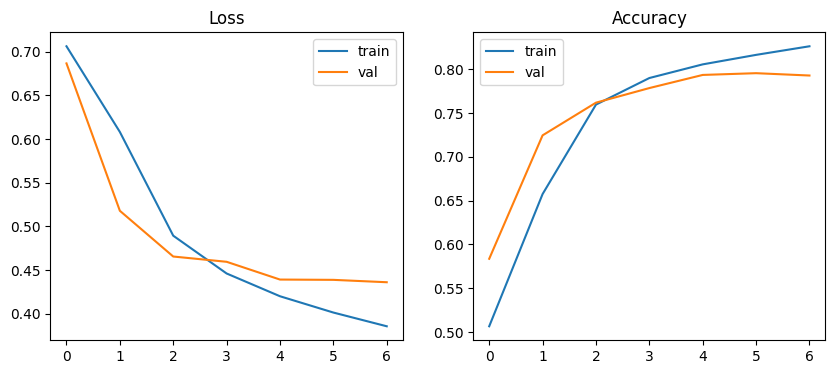

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.title("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label="train")
plt.plot(val_accs, label="val")
plt.title("Accuracy")
plt.legend()

plt.show()

## 11. 실제 테스트

In [ ]:
test_ds = ReviewSentimentDataset(test_data, tokenizer, max_length=64)
test_loader = DataLoader(test_ds, batch_size=n_batch, num_workers=n_workers)

test_loss, test_acc = evaluate_sentiment(model, test_loader, device)

print(f"test loss: {test_loss:.3f}")
print(f"test acc : {test_acc:.3f}")

test loss: 0.453
test acc : 0.788
